<a href="https://colab.research.google.com/github/brunokobi/computacao_natural/blob/main/EXC1_PSO_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🧮 Exercício Computacional 1 – Ajuste de uma curva usando algoritmos evolutivos(PSO e GA)

# dependências e helpers

In [1]:
# Célula 1: imports e helpers
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from google.colab import files
import io
import random

# configurações visuais
plt.rcParams['figure.figsize'] = (8,5)


#upload dos arquivos (execute e suba seus .txt)

In [2]:
# Célula 2: upload dos dados
print("Faça upload de x-data.txt e y-data.txt (cada um com uma coluna de valores).")
uploaded = files.upload()

def load_column_from_uploaded(name_candidates):
    for name in name_candidates:
        if name in uploaded:
            content = uploaded[name].decode('utf-8')
            arr = np.loadtxt(io.StringIO(content))
            return arr
    return None

x = load_column_from_uploaded(["x-data.txt", "x_data.txt", "x.txt", "xdata.txt"])
y = load_column_from_uploaded(["y-data.txt", "y_data.txt", "y.txt", "ydata.txt"])

if x is None or y is None:
    raise FileNotFoundError("Não encontrou x-data.txt ou y-data.txt no upload. Verifique os nomes.")

if x.shape[0] != y.shape[0]:
    raise ValueError("x e y devem ter o mesmo número de pontos (linhas).")

print(f"Dados carregados: {x.shape[0]} pontos.")


Faça upload de x-data.txt e y-data.txt (cada um com uma coluna de valores).


Saving x_data.txt to x_data.txt
Saving y_data.txt to y_data.txt
Dados carregados: 101 pontos.


#definição do modelo e função custo (SSE)

In [3]:
# Célula 3: modelo polinomial e SSE
def model(params, x):
    a, b, c = params
    return a * x**2 + b * x + c

def sse(params, x, y):
    pred = model(params, x)
    err = y - pred
    return float(np.sum(err**2))


#implementação PSO (configurável)

In [4]:
# Célula 4: PSO
def pso_optimize(cost_func, x, y, bounds,
                 swarmsize=50, maxiter=200,
                 w=0.7, c1=1.5, c2=1.5,
                 seed=None, verbose=False):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    dim = len(bounds)
    pos = np.zeros((swarmsize, dim))
    vel = np.zeros((swarmsize, dim))
    pbest_pos = np.zeros((swarmsize, dim))
    pbest_cost = np.full(swarmsize, np.inf)

    for d in range(dim):
        low, high = bounds[d]
        pos[:, d] = np.random.uniform(low, high, swarmsize)
        vel[:, d] = np.random.uniform(-(high-low), (high-low), swarmsize) * 0.1

    for i in range(swarmsize):
        pbest_pos[i] = pos[i].copy()
        pbest_cost[i] = cost_func(pos[i], x, y)

    gbest_idx = np.argmin(pbest_cost)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_cost = pbest_cost[gbest_idx]

    history = []
    for it in range(maxiter):
        for i in range(swarmsize):
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)
            vel[i] = w * vel[i] + c1 * r1 * (pbest_pos[i] - pos[i]) + c2 * r2 * (gbest_pos - pos[i])
            pos[i] = pos[i] + vel[i]
            # clamp
            for d in range(dim):
                low, high = bounds[d]
                if pos[i,d] < low:
                    pos[i,d] = low
                    vel[i,d] = 0
                if pos[i,d] > high:
                    pos[i,d] = high
                    vel[i,d] = 0
            cost = cost_func(pos[i], x, y)
            if cost < pbest_cost[i]:
                pbest_cost[i] = cost
                pbest_pos[i] = pos[i].copy()
                if cost < gbest_cost:
                    gbest_cost = cost
                    gbest_pos = pos[i].copy()
        history.append(gbest_cost)
        if verbose and it % (max(1, maxiter//10)) == 0:
            print(f"PSO iter {it}/{maxiter} best {gbest_cost:.6g}")
    return gbest_pos, float(gbest_cost), history


#implementação GA (função reutilizável)

In [5]:
# Célula 5: Algoritmo Genético (GA)
def ga_optimize(cost_func, x, y, bounds,
                pop_size=60, generations=200,
                crossover_rate=0.9, mutation_rate=0.2,
                mutation_scale=0.1,
                tournament_k=3,
                seed=None, verbose=False):
    """
    Representação: vetor real [a,b,c]
    selection: tournament
    crossover: arithmetic (blend-like)
    mutation: gaussian additive (per gene)
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    dim = len(bounds)

    # inicializa população
    pop = np.zeros((pop_size, dim))
    for d in range(dim):
        low, high = bounds[d]
        pop[:, d] = np.random.uniform(low, high, pop_size)

    # avalia
    fitness = np.array([cost_func(ind, x, y) for ind in pop])
    best_idx = np.argmin(fitness)
    best_ind = pop[best_idx].copy()
    best_cost = float(fitness[best_idx])

    history = []
    for gen in range(generations):
        new_pop = []
        # elitism: keep best
        new_pop.append(best_ind.copy())

        while len(new_pop) < pop_size:
            # selection: tournament
            def tournament_select():
                ids = np.random.choice(pop_size, tournament_k, replace=False)
                best = ids[np.argmin(fitness[ids])]
                return pop[best].copy()

            parent1 = tournament_select()
            parent2 = tournament_select()

            child1, child2 = parent1.copy(), parent2.copy()
            # crossover
            if np.random.rand() < crossover_rate:
                # arithmetic crossover (blend)
                alpha = np.random.rand(dim)
                child1 = alpha * parent1 + (1-alpha) * parent2
                child2 = alpha * parent2 + (1-alpha) * parent1

            # mutation (gaussian per gene)
            for child in (child1, child2):
                for d in range(dim):
                    if np.random.rand() < mutation_rate:
                        low, high = bounds[d]
                        scale = (high - low) * mutation_scale
                        child[d] += np.random.normal(0, scale)
                        # clamp
                        if child[d] < low: child[d] = low
                        if child[d] > high: child[d] = high

            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)

        pop = np.array(new_pop)
        fitness = np.array([cost_func(ind, x, y) for ind in pop])
        gen_best_idx = np.argmin(fitness)
        gen_best_cost = float(fitness[gen_best_idx])
        gen_best_ind = pop[gen_best_idx].copy()

        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_ind = gen_best_ind.copy()

        history.append(best_cost)
        if verbose and gen % (max(1, generations//10)) == 0:
            print(f"GA gen {gen}/{generations} best {best_cost:.6g}")

    return best_ind, best_cost, history


#parâmetros, múltiplas execuções (PSO e GA) e coleta de resultados

In [6]:
# Célula 6: configuração e execução comparativa
bounds = [(-5, 5), (-5, 5), (-5, 5)]
n_runs = 10     # número de runs independentes por algoritmo
# PSO hyperparams
pso_params = {
    "swarmsize": 60,
    "maxiter": 300,
    "w": 0.7, "c1": 1.5, "c2": 1.5
}
# GA hyperparams
ga_params = {
    "pop_size": 60,
    "generations": 300,
    "crossover_rate": 0.9,
    "mutation_rate": 0.2,
    "mutation_scale": 0.05,
    "tournament_k": 3
}

pso_results = []  # tuples (params, cost, history, seed)
ga_results = []

start_total = time.time()
for run in range(n_runs):
    seed = int(time.time()*1000) % 2**32 + run
    # PSO
    p_params, p_cost, p_hist = pso_optimize(sse, x, y, bounds,
                                           swarmsize=pso_params["swarmsize"],
                                           maxiter=pso_params["maxiter"],
                                           w=pso_params["w"], c1=pso_params["c1"], c2=pso_params["c2"],
                                           seed=seed, verbose=False)
    pso_results.append((p_params, p_cost, p_hist, seed))

    # GA (use another seed offset to diversify)
    seed_ga = (seed + 1234567) % 2**32
    g_params, g_cost, g_hist = ga_optimize(sse, x, y, bounds,
                                           pop_size=ga_params["pop_size"],
                                           generations=ga_params["generations"],
                                           crossover_rate=ga_params["crossover_rate"],
                                           mutation_rate=ga_params["mutation_rate"],
                                           mutation_scale=ga_params["mutation_scale"],
                                           tournament_k=ga_params["tournament_k"],
                                           seed=seed_ga, verbose=False)
    ga_results.append((g_params, g_cost, g_hist, seed_ga))

    print(f"Run {run+1}/{n_runs}: PSO SSE={p_cost:.6g} | GA SSE={g_cost:.6g}")

end_total = time.time()
print(f"Tempo total (ambos os algoritmos): {end_total - start_total:.2f} s")


Run 1/10: PSO SSE=8.31524e-08 | GA SSE=0.0209194
Run 2/10: PSO SSE=8.31524e-08 | GA SSE=0.016852
Run 3/10: PSO SSE=8.31524e-08 | GA SSE=0.00718391
Run 4/10: PSO SSE=8.31524e-08 | GA SSE=1.3246e-05
Run 5/10: PSO SSE=8.31524e-08 | GA SSE=0.00253378
Run 6/10: PSO SSE=8.31524e-08 | GA SSE=0.00808589
Run 7/10: PSO SSE=8.31524e-08 | GA SSE=8.61196e-08
Run 8/10: PSO SSE=8.31524e-08 | GA SSE=0.0778327
Run 9/10: PSO SSE=8.31524e-08 | GA SSE=0.119543
Run 10/10: PSO SSE=8.31524e-08 | GA SSE=0.032375
Tempo total (ambos os algoritmos): 11.19 s


#estatísticas e resumo comparativo (tabela + CSV)

In [7]:
# Célula 7: estatísticas comparativas
p_costs = np.array([r[1] for r in pso_results])
g_costs = np.array([r[1] for r in ga_results])

summary = {
    "method": ["PSO", "GA"],
    "best_SSE": [p_costs.min(), g_costs.min()],
    "mean_SSE": [p_costs.mean(), g_costs.mean()],
    "std_SSE": [p_costs.std(ddof=0), g_costs.std(ddof=0)]
}
df_summary = pd.DataFrame(summary)
print(df_summary)

# tabela detalhada por run
rows = []
for i in range(n_runs):
    rows.append({
        "run": i+1,
        "method": "PSO",
        "SSE": pso_results[i][1],
        "a": pso_results[i][0][0],
        "b": pso_results[i][0][1],
        "c": pso_results[i][0][2],
        "seed": pso_results[i][3]
    })
    rows.append({
        "run": i+1,
        "method": "GA",
        "SSE": ga_results[i][1],
        "a": ga_results[i][0][0],
        "b": ga_results[i][0][1],
        "c": ga_results[i][0][2],
        "seed": ga_results[i][3]
    })

df_runs = pd.DataFrame(rows)
df_runs.to_csv('comparison_results.csv', index=False)
print("\nResultados por run salvos em comparison_results.csv")
files.download('comparison_results.csv')


  method      best_SSE      mean_SSE       std_SSE
0    PSO  8.315238e-08  8.315238e-08  1.533234e-17
1     GA  8.611958e-08  2.853388e-02  3.754961e-02

Resultados por run salvos em comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#plot: melhor ajuste de cada método (dados + curvas)

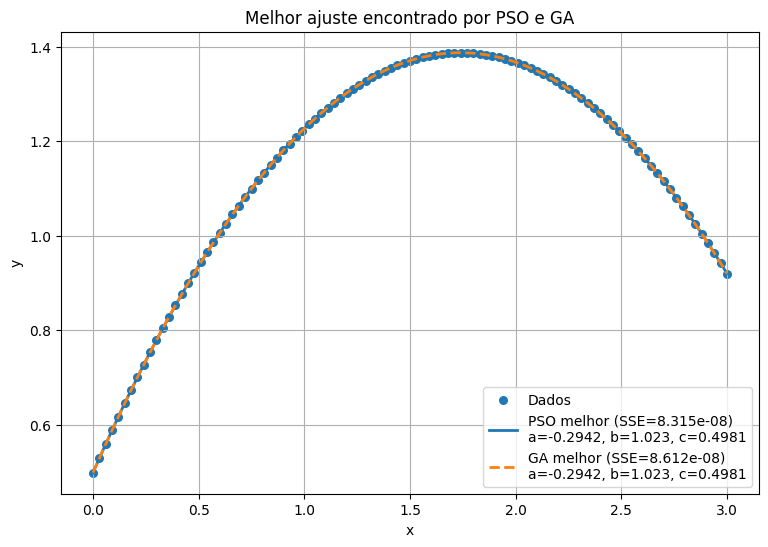

In [8]:
# Célula 8: plot do melhor ajuste de cada método
best_p_idx = int(np.argmin([r[1] for r in pso_results]))
best_g_idx = int(np.argmin([r[1] for r in ga_results]))

best_p_params = pso_results[best_p_idx][0]
best_g_params = ga_results[best_g_idx][0]

xx = np.linspace(np.min(x), np.max(x), 400)
yy_p = model(best_p_params, xx)
yy_g = model(best_g_params, xx)

plt.figure(figsize=(9,6))
plt.scatter(x, y, label='Dados', s=30)
plt.plot(xx, yy_p, label=f'PSO melhor (SSE={pso_results[best_p_idx][1]:.3e})\na={best_p_params[0]:.4g}, b={best_p_params[1]:.4g}, c={best_p_params[2]:.4g}', lw=2)
plt.plot(xx, yy_g, '--', label=f'GA melhor (SSE={ga_results[best_g_idx][1]:.3e})\na={best_g_params[0]:.4g}, b={best_g_params[1]:.4g}, c={best_g_params[2]:.4g}', lw=2)
plt.title('Melhor ajuste encontrado por PSO e GA')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()



#plot: convergência (todos os históricos) e boxplot de SSEs

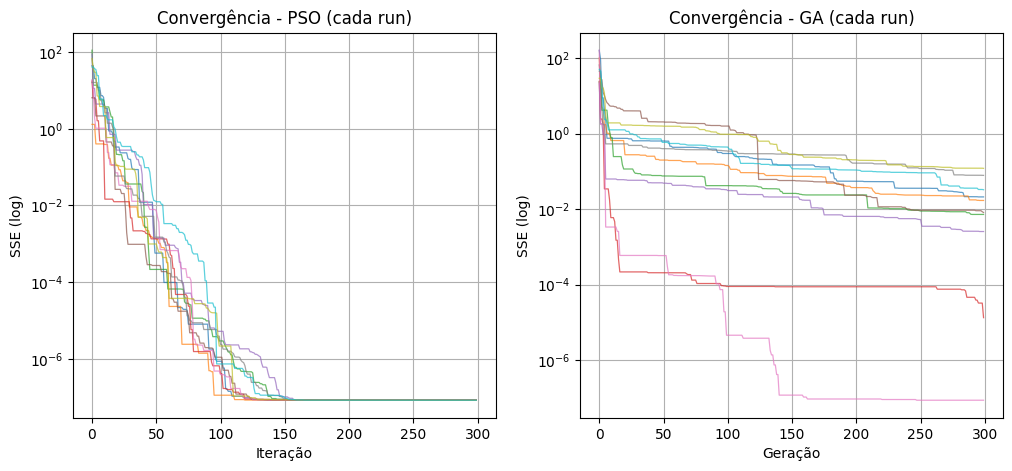

/tmp/ipython-input-1619186382.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([p_costs, g_costs], labels=['PSO','GA'], showmeans=True)


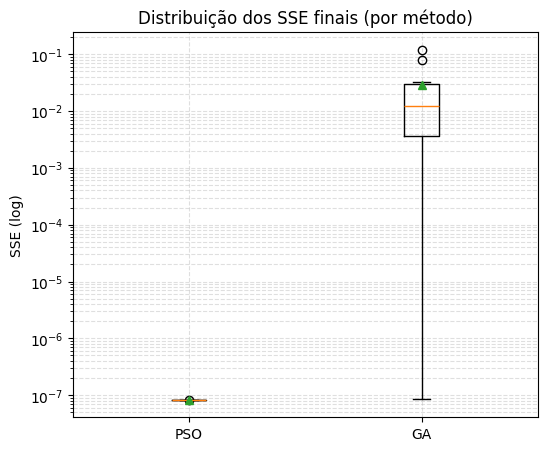

In [9]:
# Célula 9: convergência e boxplot
# Convergência PSO
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i, r in enumerate(pso_results):
    plt.plot(r[2], lw=0.9, alpha=0.7)
plt.yscale('log')
plt.title('Convergência - PSO (cada run)')
plt.xlabel('Iteração')
plt.ylabel('SSE (log)')
plt.grid(True)

# Convergência GA
plt.subplot(1,2,2)
for i, r in enumerate(ga_results):
    plt.plot(r[2], lw=0.9, alpha=0.7)
plt.yscale('log')
plt.title('Convergência - GA (cada run)')
plt.xlabel('Geração')
plt.ylabel('SSE (log)')
plt.grid(True)
plt.show()

# Boxplot dos SSEs finais
plt.figure(figsize=(6,5))
plt.boxplot([p_costs, g_costs], labels=['PSO','GA'], showmeans=True)
plt.yscale('log')
plt.title('Distribuição dos SSE finais (por método)')
plt.ylabel('SSE (log)')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()


#interpretação rápida dos resultados (texto automático)

In [10]:
# Célula 10: interpretação automática (resumo)
print("Resumo automático:")
print(f"PSO -> melhor SSE: {p_costs.min():.6g}, média: {p_costs.mean():.6g}, std: {p_costs.std(ddof=0):.6g}")
print(f"GA  -> melhor SSE: {g_costs.min():.6g}, média: {g_costs.mean():.6g}, std: {g_costs.std(ddof=0):.6g}\n")

if p_costs.mean() < g_costs.mean():
    print("No conjunto de runs, PSO apresentou média de SSE menor que GA — PSO tende a ajustar melhor, em média.")
else:
    print("No conjunto de runs, GA apresentou média de SSE menor que PSO — GA tende a ajustar melhor, em média.")

print("\nObservações (para análise humana):")
print("- Verifique se os dados possuem ruído; SSE muito baixo pode indicar overfitting ou dados perfeitamente quadráticos.")
print("- Se um método tem menor SSE médio e também menor desvio padrão, ele é mais robusto aqui.")
print("- Experimente variar hyperparâmetros (tamanho da população/partículas, iterações/gerações, taxa de mutação) para ver impacto.")


Resumo automático:
PSO -> melhor SSE: 8.31524e-08, média: 8.31524e-08, std: 1.53323e-17
GA  -> melhor SSE: 8.61196e-08, média: 0.0285339, std: 0.0375496

No conjunto de runs, PSO apresentou média de SSE menor que GA — PSO tende a ajustar melhor, em média.

Observações (para análise humana):
- Verifique se os dados possuem ruído; SSE muito baixo pode indicar overfitting ou dados perfeitamente quadráticos.
- Se um método tem menor SSE médio e também menor desvio padrão, ele é mais robusto aqui.
- Experimente variar hyperparâmetros (tamanho da população/partículas, iterações/gerações, taxa de mutação) para ver impacto.
